Ref string size:  20
Frame slots:  4
1.FIFO  2.LRU  3.OPTIMAL
Choice:  1



Algorithm: FIFO
Frames: 4
Total Pages: 20
Hits: 11
Faults: 9
Ref String:  [5, 4, 9, 6, 3, 6, 3, 9, 7, 5, 4, 6, 5, 5, 4, 7, 5, 5, 5, 5]


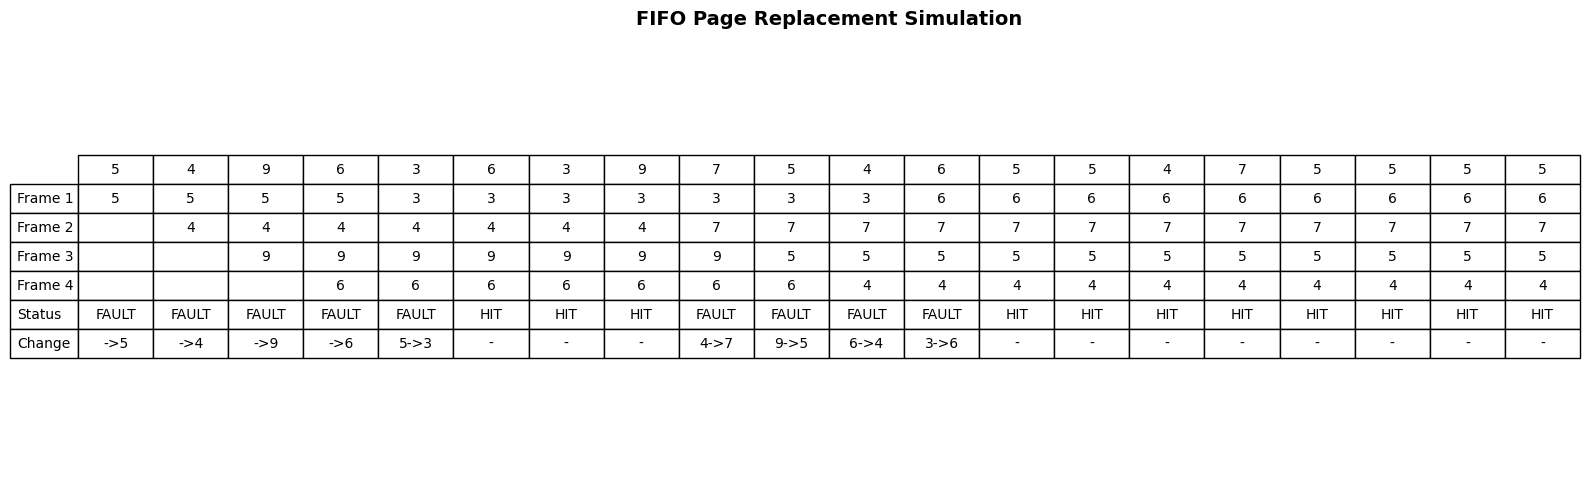

In [1]:
import random
import matplotlib.pyplot as plt

def get_victim_index(algo, frames, pages, current_idx, recent_usage, fifo_q):
    if algo == "FIFO":
        return fifo_q, (fifo_q + 1) % len(frames)
    
    if algo == "LRU":
        victim = min(frames, key=lambda x: recent_usage[x])
        return frames.index(victim), fifo_q

    if algo == "OPTIMAL":
        future = pages[current_idx+1:]
        victim = max(frames, key=lambda x: future.index(x) if x in future else float('inf'))
        return frames.index(victim), fifo_q

def simulate(pages, cap, algo):
    frames, history, status, repl_str = [], [], [], []
    faults, fifo_q = 0, 0
    recent = {}

    for i, p in enumerate(pages):
        recent[p] = i
        
        if p in frames:
            status.append("HIT"); repl_str.append("-")
        else:
            faults += 1
            status.append("FAULT")
            
            if len(frames) < cap:
                frames.append(p)
                repl_str.append(f"->{p}")
            else:
                idx, fifo_q = get_victim_index(algo, frames, pages, i, recent, fifo_q)
                repl_str.append(f"{frames[idx]}->{p}")
                frames[idx] = p
        
        history.append(frames[:])

    return faults, history, status, repl_str

try:
    n = int(input("Ref string size: "))
    cap = int(input("Frame slots: "))
    choice = int(input("1.FIFO  2.LRU  3.OPTIMAL\nChoice: "))
    algos = {1: "FIFO", 2: "LRU", 3: "OPTIMAL"}
    algo = algos[choice]
except (ValueError, KeyError):
    exit("Invalid Input")

pages = [random.randint(1, 9) for _ in range(n)]
faults, history, status, repl = simulate(pages, cap, algo)

print(f"\nAlgorithm: {algo}\nFrames: {cap}\nTotal Pages: {n}\nHits: {n-faults}\nFaults: {faults}\nRef String:  {pages}")

table_data = [
    [h[i] if i < len(h) else "" for h in history] 
    for i in range(cap)
] + [status, repl]

row_labels = [f"Frame {i+1}" for i in range(cap)] + ["Status", "Change"]

plt.figure(figsize=(max(10, n*0.8), 5))
plt.axis('off')
plt.title(f"{algo} Page Replacement Simulation", fontsize=14, weight='bold')
tbl = plt.table(cellText=table_data, rowLabels=row_labels, colLabels=list(map(str, pages)), loc='center', cellLoc='center')
tbl.scale(1, 1.5)
plt.tight_layout()
plt.show()

Ref string size:  20
Frame slots:  4
1.FIFO  2.LRU  3.OPTIMAL
Choice:  2



Algorithm: LRU
Frames: 4
Total Pages: 20
Hits: 4
Faults: 16
Ref String:  [6, 4, 5, 7, 1, 6, 6, 8, 8, 4, 2, 4, 5, 6, 1, 8, 2, 5, 1, 6]


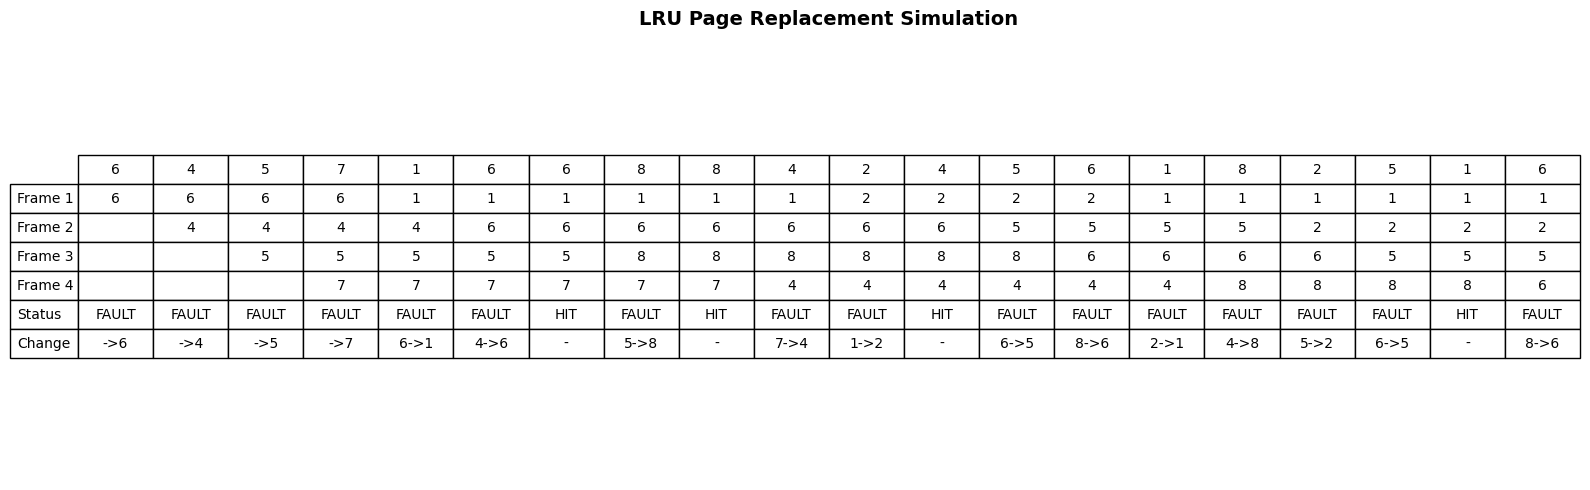

In [2]:
import random
import matplotlib.pyplot as plt

def get_victim_index(algo, frames, pages, current_idx, recent_usage, fifo_q):
    if algo == "FIFO":
        return fifo_q, (fifo_q + 1) % len(frames)
    
    if algo == "LRU":
        victim = min(frames, key=lambda x: recent_usage[x])
        return frames.index(victim), fifo_q

    if algo == "OPTIMAL":
        future = pages[current_idx+1:]
        victim = max(frames, key=lambda x: future.index(x) if x in future else float('inf'))
        return frames.index(victim), fifo_q

def simulate(pages, cap, algo):
    frames, history, status, repl_str = [], [], [], []
    faults, fifo_q = 0, 0
    recent = {}

    for i, p in enumerate(pages):
        recent[p] = i
        
        if p in frames:
            status.append("HIT"); repl_str.append("-")
        else:
            faults += 1
            status.append("FAULT")
            
            if len(frames) < cap:
                frames.append(p)
                repl_str.append(f"->{p}")
            else:
                idx, fifo_q = get_victim_index(algo, frames, pages, i, recent, fifo_q)
                repl_str.append(f"{frames[idx]}->{p}")
                frames[idx] = p
        
        history.append(frames[:])

    return faults, history, status, repl_str

try:
    n = int(input("Ref string size: "))
    cap = int(input("Frame slots: "))
    choice = int(input("1.FIFO  2.LRU  3.OPTIMAL\nChoice: "))
    algos = {1: "FIFO", 2: "LRU", 3: "OPTIMAL"}
    algo = algos[choice]
except (ValueError, KeyError):
    exit("Invalid Input")

pages = [random.randint(1, 9) for _ in range(n)]
faults, history, status, repl = simulate(pages, cap, algo)

print(f"\nAlgorithm: {algo}\nFrames: {cap}\nTotal Pages: {n}\nHits: {n-faults}\nFaults: {faults}\nRef String:  {pages}")

table_data = [
    [h[i] if i < len(h) else "" for h in history] 
    for i in range(cap)
] + [status, repl]

row_labels = [f"Frame {i+1}" for i in range(cap)] + ["Status", "Change"]

plt.figure(figsize=(max(10, n*0.8), 5))
plt.axis('off')
plt.title(f"{algo} Page Replacement Simulation", fontsize=14, weight='bold')
tbl = plt.table(cellText=table_data, rowLabels=row_labels, colLabels=list(map(str, pages)), loc='center', cellLoc='center')
tbl.scale(1, 1.5)
plt.tight_layout()
plt.show()

Ref string size:  20
Frame slots:  4
1.FIFO  2.LRU  3.OPTIMAL
Choice:  1



Algorithm: FIFO
Frames: 4
Total Pages: 20
Hits: 9
Faults: 11
Ref String:  [1, 2, 9, 7, 8, 7, 5, 7, 5, 2, 6, 7, 5, 6, 7, 8, 7, 6, 8, 1]


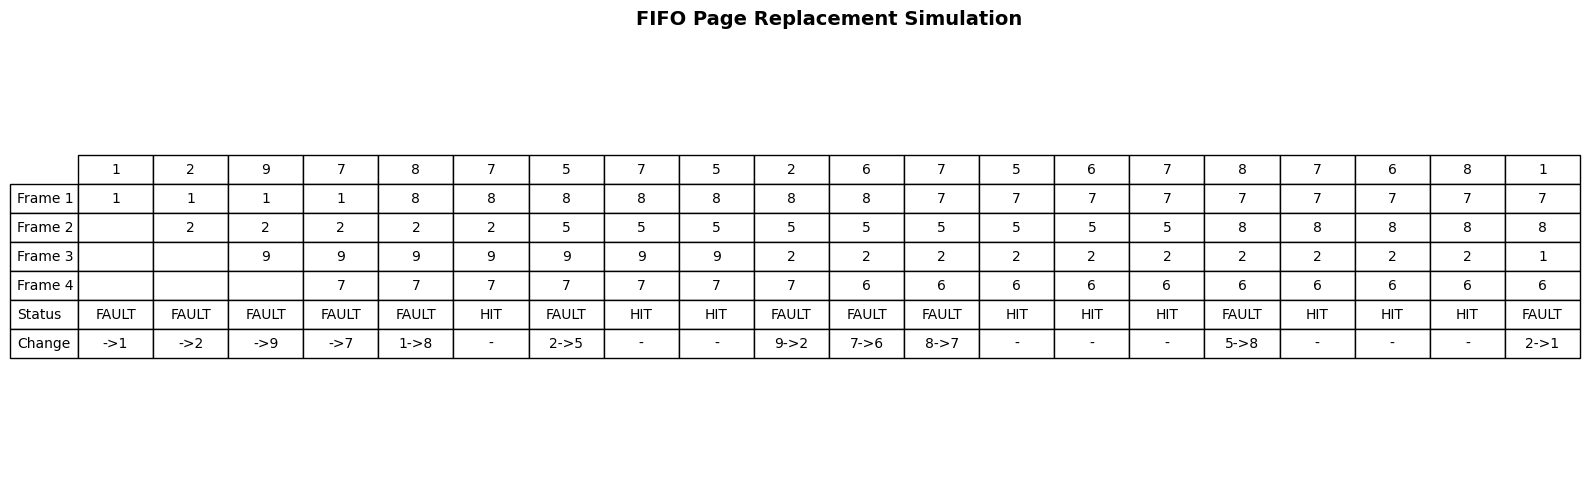

Ref string size:  20
Frame slots:  4
1.FIFO  2.LRU  3.OPTIMAL
Choice:  3



Algorithm: OPTIMAL
Frames: 4
Total Pages: 20
Hits: 11
Faults: 9
Ref String:  [8, 5, 2, 5, 8, 9, 3, 9, 2, 3, 8, 4, 2, 7, 4, 4, 6, 2, 5, 7]


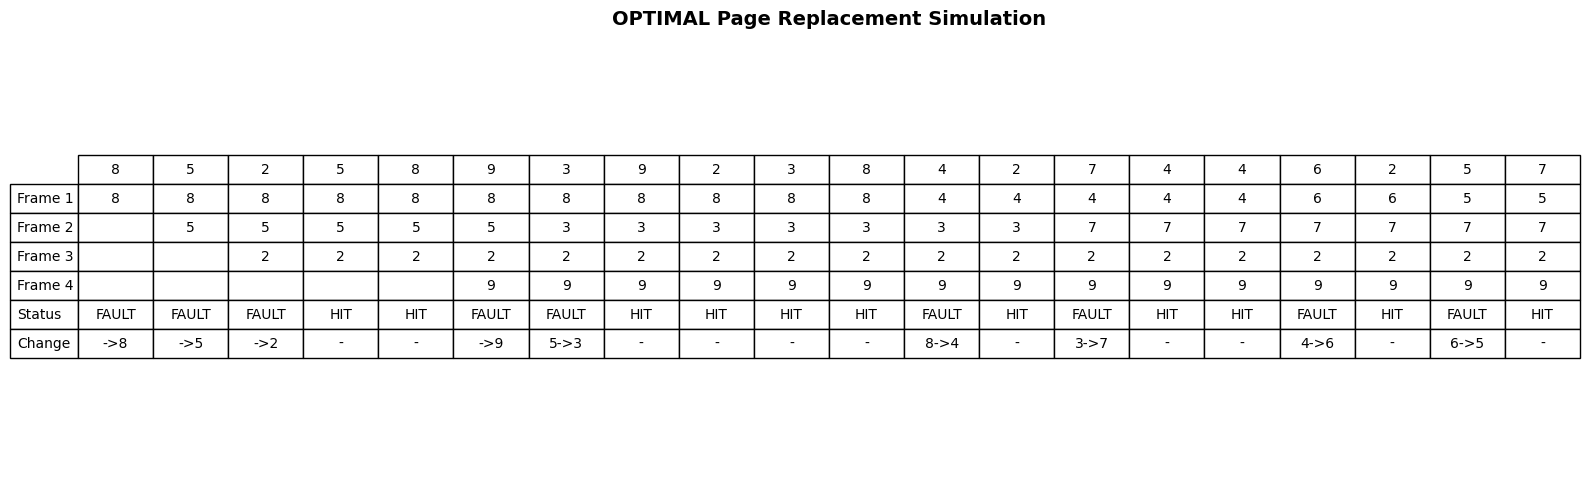

In [3]:
import random
import matplotlib.pyplot as plt

def get_victim_index(algo, frames, pages, current_idx, recent_usage, fifo_q):
    if algo == "FIFO":
        return fifo_q, (fifo_q + 1) % len(frames)
    
    if algo == "LRU":
        victim = min(frames, key=lambda x: recent_usage[x])
        return frames.index(victim), fifo_q

    if algo == "OPTIMAL":
        future = pages[current_idx+1:]
        victim = max(frames, key=lambda x: future.index(x) if x in future else float('inf'))
        return frames.index(victim), fifo_q

def simulate(pages, cap, algo):
    frames, history, status, repl_str = [], [], [], []
    faults, fifo_q = 0, 0
    recent = {}

    for i, p in enumerate(pages):
        recent[p] = i
        
        if p in frames:
            status.append("HIT"); repl_str.append("-")
        else:
            faults += 1
            status.append("FAULT")
            
            if len(frames) < cap:
                frames.append(p)
                repl_str.append(f"->{p}")
            else:
                idx, fifo_q = get_victim_index(algo, frames, pages, i, recent, fifo_q)
                repl_str.append(f"{frames[idx]}->{p}")
                frames[idx] = p
        
        history.append(frames[:])

    return faults, history, status, repl_str

try:
    n = int(input("Ref string size: "))
    cap = int(input("Frame slots: "))
    choice = int(input("1.FIFO  2.LRU  3.OPTIMAL\nChoice: "))
    algos = {1: "FIFO", 2: "LRU", 3: "OPTIMAL"}
    algo = algos[choice]
except (ValueError, KeyError):
    exit("Invalid Input")

pages = [random.randint(1, 9) for _ in range(n)]
faults, history, status, repl = simulate(pages, cap, algo)

print(f"\nAlgorithm: {algo}\nFrames: {cap}\nTotal Pages: {n}\nHits: {n-faults}\nFaults: {faults}\nRef String:  {pages}")

table_data = [
    [h[i] if i < len(h) else "" for h in history] 
    for i in range(cap)
] + [status, repl]

row_labels = [f"Frame {i+1}" for i in range(cap)] + ["Status", "Change"]

plt.figure(figsize=(max(10, n*0.8), 5))
plt.axis('off')
plt.title(f"{algo} Page Replacement Simulation", fontsize=14, weight='bold')
tbl = plt.table(cellText=table_data, rowLabels=row_labels, colLabels=list(map(str, pages)), loc='center', cellLoc='center')
tbl.scale(1, 1.5)
plt.tight_layout()
plt.show()